In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from figure_styles import construct_plot

# Allow importing the package from the repo root
sys.path.insert(0, str(Path(".").resolve().parent))

from qaoa_parameter_setting.utils.database.results_database import ResultsDatabase

import figure_styles

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# ── constants ────────────────────────────────────────────────────────────────
NUM_FILES   = 10   
DATA_DIR    = "../data/training/random_regular"

MPS_BOND_DIM = 32     
MPS_DEPTHS   = [2, 4, 6, 8]

METHOD_LEGEND_TITLE      = "Parameter setting method"
EVALUATION_LEGEND_TITLE  = "Energy evaluation method"

MPS_METHOD_LABELS = [
    "TQA*",
    "Fixed Angles*",
    "Interp.*",
    "Fourier*",
]
SV_METHOD_LABELS = [
    "TQA*",
    "Interp.*",
    "Fourier*",
    "Recursive TS*",
    "Fixed Angles*",
]

In [3]:
# ── Load all data via ResultsDatabase ────────────────────────────────────────

warnings.filterwarnings("ignore")

# MPS panels: N=40, random-3-regular
db_mps_mis = ResultsDatabase(problem_class="MIS", num_nodes=[40])
db_mps_mis.add_data(DATA_DIR)

db_mps_mc = ResultsDatabase(problem_class="MC", num_nodes=[40])
db_mps_mc.add_data(DATA_DIR)

# SV panels: N=20, random-3-regular
db_sv_mis = ResultsDatabase(problem_class="MIS", num_nodes=[20])
db_sv_mis.add_data(DATA_DIR)

db_sv_mc = ResultsDatabase(problem_class="MC", num_nodes=[20])
db_sv_mc.add_data(DATA_DIR)


def _best_df_mps(db, graph_type_filter, bond_dim):
    """One best MPS result per (instance, method_label, depth) at a fixed bond dim.
    """
    df = db.to_dataframe().pipe(lambda d: d[
        (d["evaluation_label"] == "MPS (Quimb)")
        & d["instance"].str.contains(graph_type_filter)
        & (d["mps_bond_dimension"] == bond_dim)
        & d["method_label"].isin(MPS_METHOD_LABELS)
    ]).copy()

    df["_src_depth"] = (
        df["source_file"]
        .str.extract(r'_(\d+)\.json$', expand=False)
        .astype(int)
    )
    df = (
        df
        .sort_values(
            ["_src_depth", "run_datetime", "energy"],
            ascending=[False, False, False],
        )
        .drop_duplicates(subset=["instance", "method_label", "depth"])
        .drop(columns=["_src_depth"])
    )
    return df


def _best_df_sv(db, graph_type_filter):
    """One best SV result per (instance, method_label, depth)."""
    df = db.to_dataframe().pipe(lambda d: d[
        (d["evaluation_label"] == "SV")
        & d["instance"].str.contains(graph_type_filter)
        & d["method_label"].isin(SV_METHOD_LABELS)
    ]).copy()
    df["_src_depth"] = (
        df["source_file"]
        .str.extract(r'_(\d+)\.json$', expand=False)
        .astype(int)
    )
    df = (
        df
        .sort_values(
            ["_src_depth", "run_datetime", "energy"],
            ascending=[False, False, False],
        )
        .drop_duplicates(subset=["instance", "method_label", "depth"])
        .drop(columns=["_src_depth"])
    )
    return df


df_mps_mis = _best_df_mps(db_mps_mis, "random3regular", MPS_BOND_DIM)
df_mps_mc  = _best_df_mps(db_mps_mc,  "random3regular", MPS_BOND_DIM)
df_sv_mis  = _best_df_sv(db_sv_mis,   "random3regular")
df_sv_mc   = _best_df_sv(db_sv_mc,    "random3regular")

print(
    f"Rows loaded — "
    f"MPS (BD={MPS_BOND_DIM}): MIS={len(df_mps_mis)}, MC={len(df_mps_mc)}  "
    f"| SV: MIS={len(df_sv_mis)}, MC={len(df_sv_mc)}"
)

Rows loaded — MPS (BD=32): MIS=270, MC=320  | SV: MIS=500, MC=500


In [4]:
# ── Coverage report ──────────────────────────────────────────────────────────
# For every (method, depth) combination, print n and flag n < NUM_FILES.

def report_coverage(label, df, method_labels, depths=None):
    print(f"[{label}]")
    sub = df[df["method_label"].isin(method_labels)]
    if depths is not None:
        sub = sub[sub["depth"].isin(depths)]
    stats = (
        sub.groupby(["method_label", "depth"])["instance"]
        .count()
        .reset_index(name="n")
    )
    for _, row in stats.iterrows():
        flag = " *** BELOW TARGET ***" if row["n"] < NUM_FILES else ""
        print(
            f"  method={row['method_label']!r:20s}  depth={row['depth']:2d}  "
            f"n={row['n']}/{NUM_FILES}{flag}"
        )


report_coverage("MIS MPS (axs[0, 0])", df_mps_mis, MPS_METHOD_LABELS, MPS_DEPTHS)
print()
report_coverage("MC  MPS (axs[1, 0])", df_mps_mc,  MPS_METHOD_LABELS, MPS_DEPTHS)
print()
report_coverage("MIS SV  (axs[0, 1])", df_sv_mis,  SV_METHOD_LABELS)
print()
report_coverage("MC  SV  (axs[1, 1])", df_sv_mc,   SV_METHOD_LABELS)

[MIS MPS (axs[0, 0])]
  method='Fixed Angles*'       depth= 2  n=10/10
  method='Fixed Angles*'       depth= 4  n=10/10
  method='Fixed Angles*'       depth= 6  n=10/10
  method='Fixed Angles*'       depth= 8  n=10/10
  method='Fourier*'            depth= 2  n=10/10
  method='Fourier*'            depth= 4  n=10/10
  method='Fourier*'            depth= 6  n=10/10
  method='Fourier*'            depth= 8  n=10/10
  method='Interp.*'            depth= 2  n=10/10
  method='Interp.*'            depth= 4  n=10/10
  method='Interp.*'            depth= 6  n=10/10
  method='Interp.*'            depth= 8  n=10/10
  method='TQA*'                depth= 2  n=10/10
  method='TQA*'                depth= 4  n=10/10
  method='TQA*'                depth= 6  n=10/10
  method='TQA*'                depth= 8  n=10/10

[MC  MPS (axs[1, 0])]
  method='Fixed Angles*'       depth= 2  n=10/10
  method='Fixed Angles*'       depth= 4  n=10/10
  method='Fixed Angles*'       depth= 6  n=10/10
  method='Fixed Angles*'

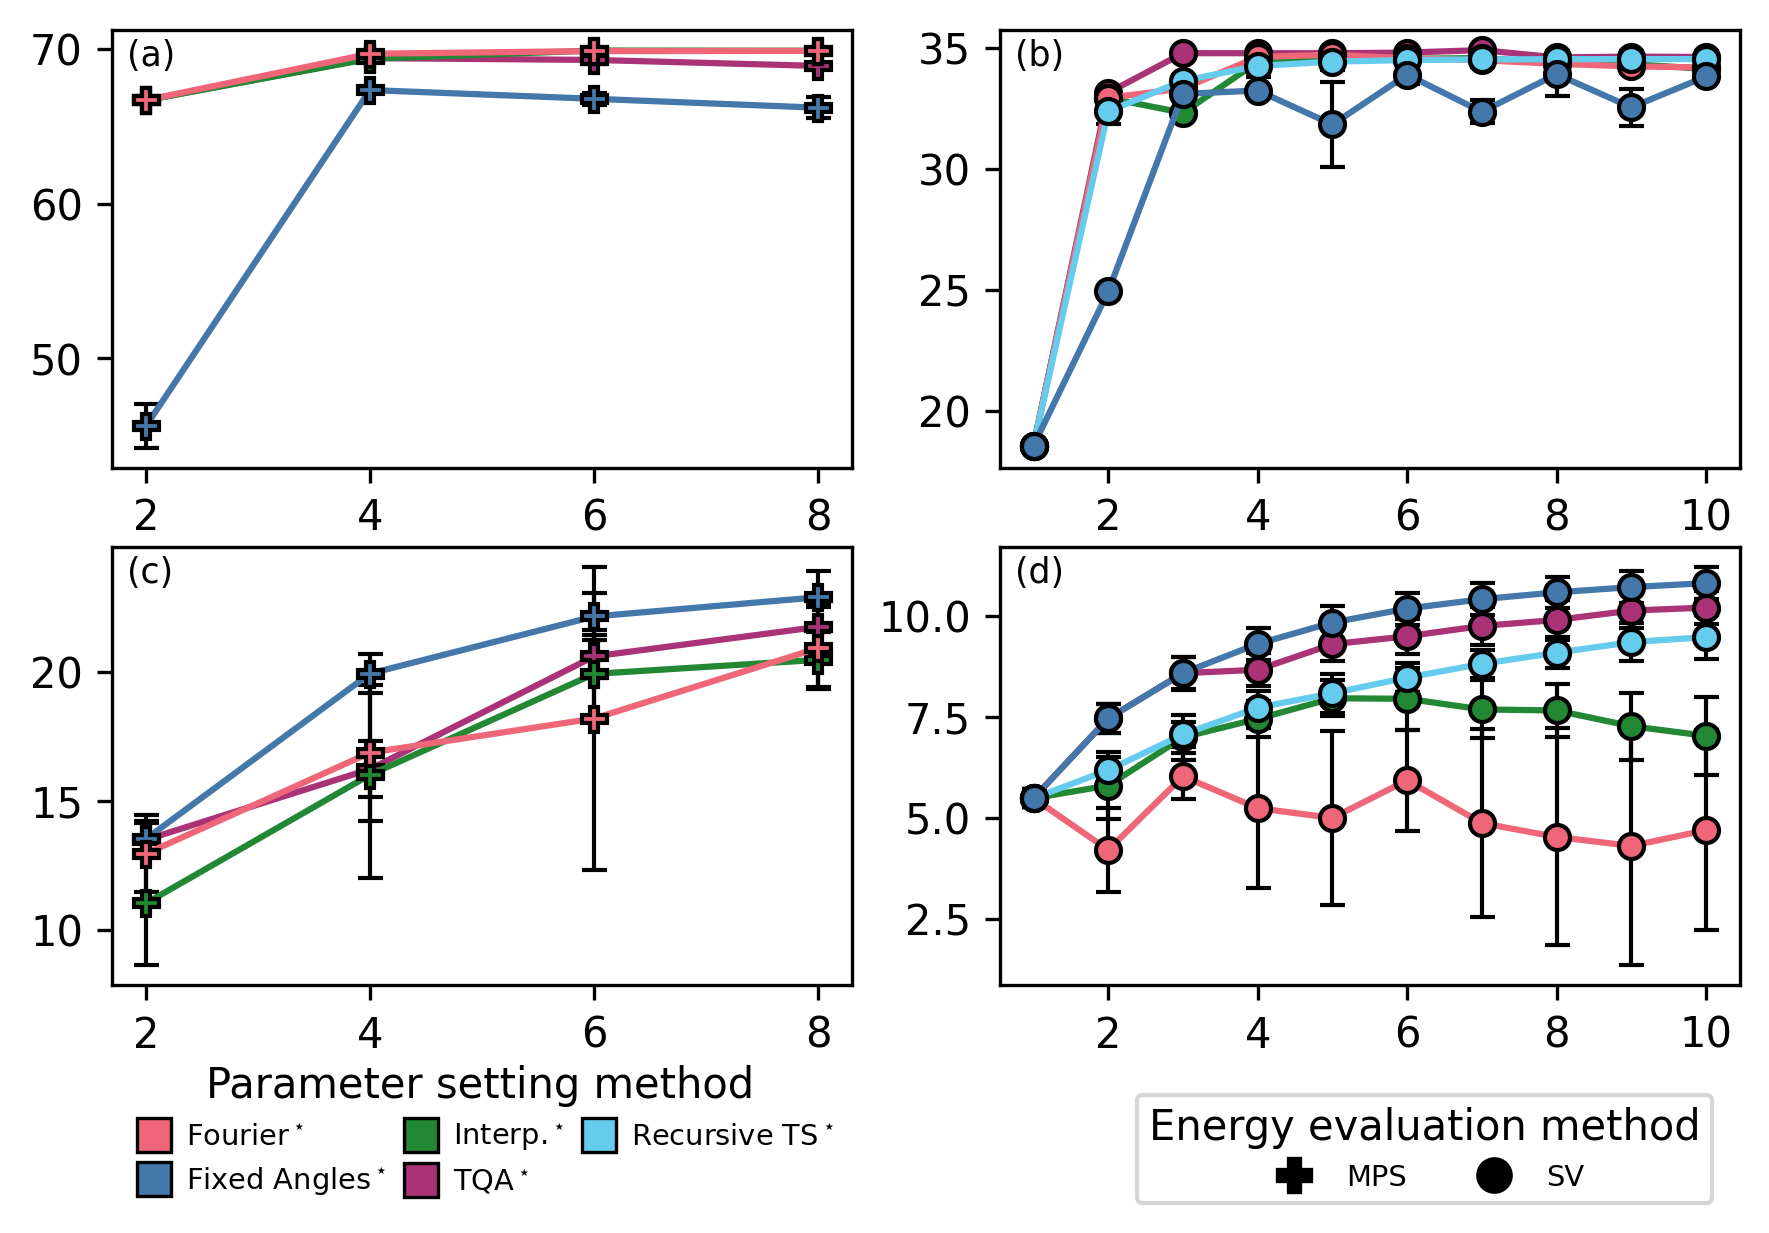

In [5]:
def _plot_panel(ax, df, method_labels, evaluation, depths=None):
    """Plot mean±std errorbar curves for each method_label onto ax."""
    sub = df[df["method_label"].isin(method_labels)]
    if depths is not None:
        sub = sub[sub["depth"].isin(depths)]
    for method_label in method_labels:
        rows = sub[sub["method_label"] == method_label]
        if rows.empty:
            continue
        stats = (
            rows.groupby("depth")["energy"]
            .agg(mean="mean", std="std")
            .reset_index()
            .sort_values("depth")
        )
        ax.errorbar(
            stats["depth"].to_numpy(),
            stats["mean"].to_numpy(),
            yerr=stats["std"].to_numpy(),
            label=figure_styles.format_method_label(method_label),
            **figure_styles.style_errorbar(method_label, evaluation),
        )
method_legend_items = [
    ("Fourier",           "Fourier"),
    ("Fixed Angles*",     "Fixed Angles*"),
    ("INTERP",            "INTERP"),
    ("TQA*",              "TQA*"),
    ("Transition States", "Transition States"),
]
evaluation_legend_items = [
    ("MPS", "MPS"),
    ("SV",  "SV"),
]

method_handles = [
    figure_styles.method_legend_handle(
        figure_styles.format_method_label(label), method
    )
    for label, method in method_legend_items
]
evaluation_handles = [
    figure_styles.evaluation_legend_handle(label, evaluation)
    for label, evaluation in evaluation_legend_items
]

layout = construct_plot(2, 2, two_columns=True, aspect_ratio=1/0.65, n_legends=2, method_ncol= 3)
_plot_panel(layout.axs[0][0], df_mps_mis, MPS_METHOD_LABELS, "MPS", MPS_DEPTHS)
_plot_panel(layout.axs[1][0], df_mps_mc,  MPS_METHOD_LABELS, "MPS", MPS_DEPTHS)
_plot_panel(layout.axs[0][1], df_sv_mis,  SV_METHOD_LABELS,  "SV")
_plot_panel(layout.axs[1][1], df_sv_mc,   SV_METHOD_LABELS,  "SV")
layout.fig.legend(handles=method_handles, title="Parameter setting method", **layout.method_legend_kw)
layout.fig.legend(handles=evaluation_handles,   title="Energy evaluation method", **layout.evaluation_legend_kw)
figure_styles.add_panel_labels(layout.flat_axes())
layout.apply_subplots_adjust()
layout.fig.savefig("figure_17.pdf", **figure_styles.savefig_kwargs())